In [1]:
import furuta_systems
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import furuta_params
import furuta_trajectory_gen
from IPython.display import display, Math
import scipy

# Überführung und Regelung in der stabilen Ruhelage (mit reduziertem Beobachter)


## Erweitern Sie die Simulation aus 3.11 um einen reduzierten linearen Beobachter, der die nicht messbaren Winkelgeschwindigkeiten, unter Verwendung der bekannten Messungen rekonstruiert.

### a) Entwerfen Sie auf Basis des linearisierten Modells aus 3.9 einen reduzierten Beobachter.

### b) Implementieren und integrieren Sie den Beobachter in Ihre Simulationsumgebung und den Regelkreis aus 3.11, um die nicht messbaren Winkelgeschwindigkeiten für den Regler damit zu bestimmen.

### c) Vergleichen Sie die Ergebnisse mit denen aus 3.11.

In [2]:
params_auslegung = furuta_params.FurutaParams()
params_auslegung.mu_H1 = 0.0
params_auslegung.mu_H2 = 0.0
operating_point = (0,0,0,0,0)
haft_reibung = True #legt fest ob die Haftreibung im nicht linearen Modell (simulation) existiert

params_sim = furuta_params.FurutaParams()
if not haft_reibung:
    params_sim.mu_H1 = 0.0
    params_sim.mu_H2 = 0.0

# Ausgang gleich Theta1 setzen um später b0 zu berechnen
cT = np.array([[1, 0, 0, 0]])

y0 = 0.0
yT = (140.0/360.0) * 2 * np.pi
t0 = 0
t1 = 2.5

x0 = [0.0, 0.0, 0.0, 0.0]
t_sim = np.linspace(0.0, 10.0, 10000)

#Regler Parameter (harmonischer Oszillator)
omega0_scaler = 1.0 #omega0 = max. eigenwert von A
D = -0.5
D_down = 1.01 * D

### Regler Verstärkung berechnen

In [3]:
A, b = furuta_systems.get_linear_furuta(params_auslegung, operating_point)
eigvals = np.linalg.eigvals(A)
omega0 = float(omega0_scaler * np.max(np.abs(eigvals)))

imag = np.sqrt(1.0 - D**2)
k_res = scipy.signal.place_poles(A, b, (D*omega0, D_down*omega0, omega0*(D+1j*imag), omega0*(D-1j*imag)))
k = k_res.gain_matrix

### Trajektorie berechnen

In [4]:

b0, b1, b2, b3 = furuta_systems.get_b_coefficients_furuta(cT, params_auslegung, operating_point)

eta0 = y0/b0
etaT = yT/b0

u_ref, x_ref = furuta_trajectory_gen.generate_trajectorys(eta0, etaT, t0, t1, params_auslegung, operating_point)

### Reduzierter Beobachter

In [5]:
A11 = np.array([[A[0][0], A[0][2]], [A[2][0], A[2][2]]])
A22 = np.array([[A[1][1], A[1][3]], [A[3][1], A[3][3]]])
A12T = np.array([[A[0][1], A[0][3]], [A[2][1], A[2][3]]])
A21 = np.array([[A[1][0], A[1][2]], [A[3][0], A[3][2]]])
b1 = np.array([[b[0][0]], [b[2][0]]])
b2 = np.array([[b[1][0]], [b[3][0]]])

In [6]:
from scipy.linalg import solve_continuous_are

Q = np.array([[50, 0], [0, 30]])
R = np.array([[1, 0], [0, 0.1]])

#alt
#P = solve_continuous_are(A22.T, A12, Q, R)
#L = (np.linalg.inv(R) * (A12 @ P)).T

P = solve_continuous_are(A22.T, A12T, Q, R)
L = P @ A12T @ np.linalg.inv(R)


def reduced_observer(t, zeta, y, u):
    zeta_d = (A22 - L@A12T)@zeta + ((A22 - L@A12T)@L - A11@L + A21)@y + (b2 - L@b1) * u
    return zeta_d

### Simulation:

In [7]:
non_linear_furuta_system = furuta_systems.get_non_linear_furuta_system(params_sim)

def simulation_system_2FHG_with_observer(t, s):
    x = s[:4]
    zeta = s[4:].reshape(2, 1)
    y_obs = np.array([[x[0]], [x[2]]])

    x2_hat = zeta + L@y_obs
   
    x_obs = np.array([x[0], x2_hat[0, 0], x[2], x2_hat[1, 0]])
    
    u = u_ref(t) - k @ (x_obs - x_ref(t))

    x_dot = non_linear_furuta_system(t, x, u)
    zeta_dot = reduced_observer(t, zeta, y_obs, u)

    return np.concatenate([x_dot, zeta_dot.flatten()])

s0 = np.concatenate([x0, np.zeros(2)])

sol = solve_ivp(
    simulation_system_2FHG_with_observer,
    (float(t_sim[0]), float(t_sim[-1])),
    s0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

### Winkel Plotten

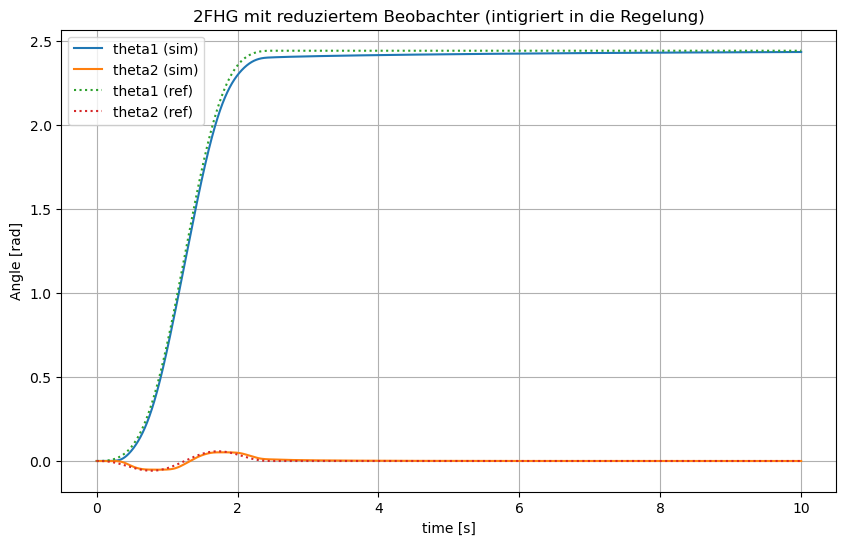

In [8]:
#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("2FHG mit reduziertem Beobachter (intigriert in die Regelung)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

### Winkelgeschwindigkeiten Plotten

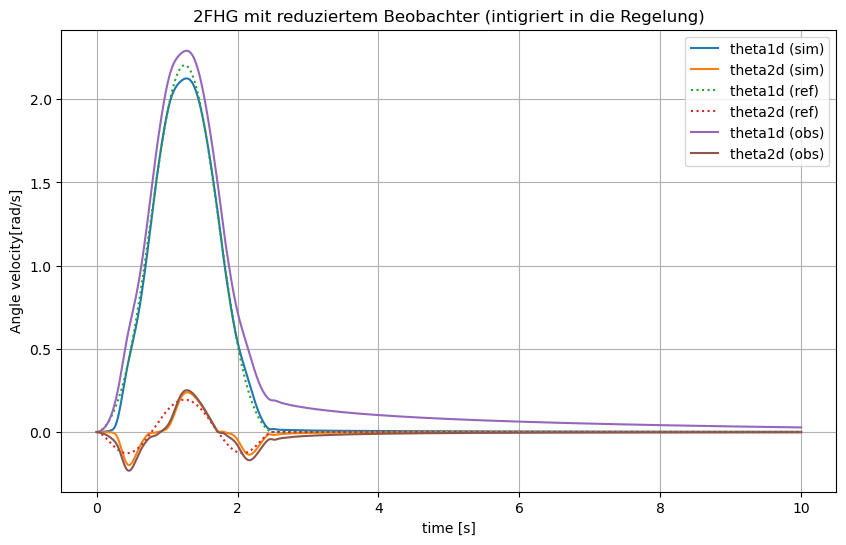

In [9]:
#plot sim angles
theta1d_sim = sol.y[1]
theta2d_sim = sol.y[3]

#plot x_ref
theta1d_ref = np.array([x_ref(t)[1] for t in t_sim])
theta2d_ref = np.array([x_ref(t)[3] for t in t_sim])

# sol.y shape: (6, N)
zeta_log = sol.y[4:6, :].T     # shape: (N, 2)
y_log   = sol.y[[0, 2], :].T  # shape: (N, 2)

# l shape: (2, 2)
x2_hat_log = zeta_log + (L @ y_log.T).T   # shape: (N, 2)

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1d_sim, label="theta1d (sim)")
plt.plot(t_sim, theta2d_sim, label="theta2d (sim)")
plt.plot(t_sim, theta1d_ref, label="theta1d (ref)", linestyle=':')
plt.plot(t_sim, theta2d_ref, label="theta2d (ref)", linestyle=':')

plt.plot(t_sim, x2_hat_log[:, 0], label="theta1d (obs)")
plt.plot(t_sim, x2_hat_log[:, 1], label="theta2d (obs)")


plt.title("2FHG mit reduziertem Beobachter (intigriert in die Regelung)")
plt.ylabel("Angle velocity[rad/s]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()